In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

e:\parity-patterns-sri-lanka-main\parity-patterns-sri-lanka\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [2]:
from pathlib import Path

In [3]:
# Define paths
DATA_PATH = Path("../../../data/raw")

In [4]:
# Load data
df = pd.read_excel(DATA_PATH / "2010_Birth_Final.xlsx")

In [5]:
# Quick exploration
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 363863 entries, 0 to 363862
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Registered_Year          363862 non-null  float64
 1   Registered_Month2.0      363862 non-null  float64
 2   Registered_Month         363862 non-null  str    
 3   Registered_District_2.0  363862 non-null  float64
 4   Registered_District      363862 non-null  str    
 5   Birh_Year                363862 non-null  float64
 6   Birth_Month.0            363862 non-null  float64
 7   Birth_Month              363862 non-null  str    
 8   Gender                   363862 non-null  str    
 9   Hospital or Not          363862 non-null  str    
 10  Multiple_Birth_Status    363862 non-null  str    
 11  Birth_Weight(grams)      318576 non-null  float64
 12  Birth_Order              363846 non-null  str    
 13  Age of Mother            363862 non-null  float64
 14  Marital_Status 

,Registered_Year,Registered_Month2.0,Registered_District_2.0,Birh_Year,Birth_Month.0,Birth_Weight(grams),Age of Mother
count,363862.0,363862.000000,363862.000000,363862.000000,363862.000000,318576.000000,363862.000000
mean,2010.0,6.641007,41.603075,2009.569087,6.597163,2887.466068,28.473333
std,0.0,3.433100,27.110147,2.690657,3.420695,483.212589,5.744939
min,2010.0,1.000000,11.000000,1950.000000,1.000000,400.000000,12.000000
25%,2010.0,4.000000,13.000000,2010.000000,4.000000,2600.000000,24.000000
50%,2010.0,7.000000,33.000000,2010.000000,7.000000,2900.000000,28.000000
75%,2010.0,10.000000,62.000000,2010.000000,10.000000,3200.000000,32.000000
max,2010.0,12.000000,92.000000,2010.000000,12.000000,6070.000000,54.000000


In [6]:


# Create missing values table
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append({
        'Variable': col,
        'Missing Count': missing_count,
        'Missing %': round(missing_percent, 1),
        'Data Type': str(df[col].dtype),
        'Unique Values': df[col].nunique()
    })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Save to Excel with formatting
with pd.ExcelWriter('01_missing_values.xlsx', engine='openpyxl') as writer:
    missing_df.to_excel(writer, sheet_name='Missing Values', index=False)
    
    # Auto-fit columns
    worksheet = writer.sheets['Missing Values']
    for column in worksheet.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        worksheet.column_dimensions[column_letter].width = adjusted_width

print("✅ Saved: 01_missing_values.xlsx")

✅ Saved: 01_missing_values.xlsx


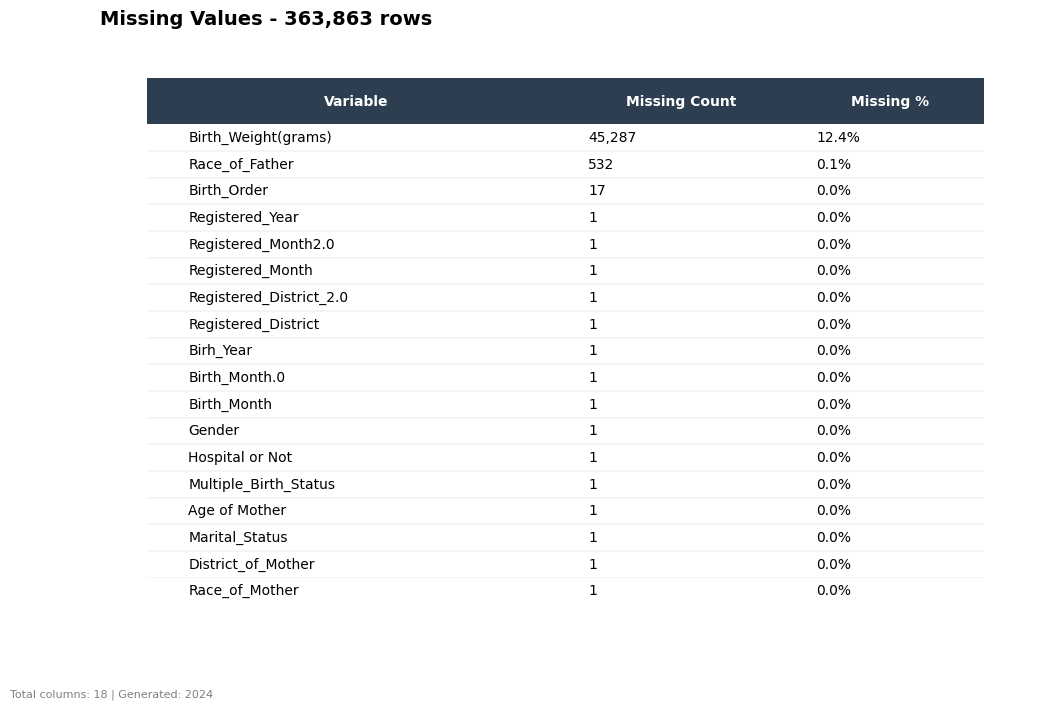

✅ Saved: missing_values_clean.png


In [7]:


# Prepare data
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append([col, f"{missing_count:,}", f"{missing_percent:.1f}%"])

# Sort by missing count
missing_data.sort(key=lambda x: int(x[1].replace(',', '')), reverse=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Create table
tbl = ax.table(cellText=missing_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# Style - CLEAN horizontal lines only
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)  # Remove all borders
    cell.set_edgecolor('white')
    
    if row == 0:  # Header
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(weight='bold', color='white')
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black')
        
        # Add subtle horizontal line below each row
        if row < len(missing_data):  # All rows except last
            cell.set_edgecolor('#cccccc')
            cell.set_linewidth(0.3)
            cell.visible_edges = 'B'  # Bottom edge only

plt.title(f'Missing Values - {len(df):,} rows', 
          fontsize=14, fontweight='bold', pad=20, loc='left')

# Add small footer
plt.figtext(0.05, 0.02, f'Total columns: {len(df.columns)} | Generated: 2024', 
            fontsize=8, color='gray')

plt.savefig('missing_values_clean.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            pad_inches=0.3)
plt.show()

print("✅ Saved: missing_values_clean.png")

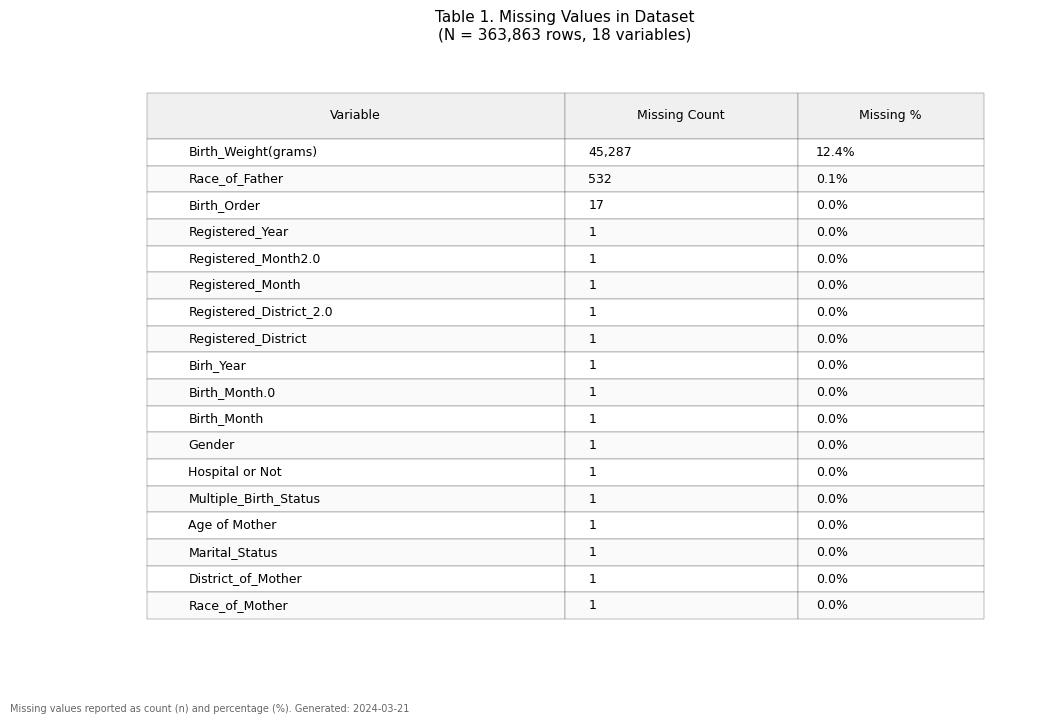

✅ Saved: missing_values_iupac.png (IUPAC compliant)


In [8]:
# Prepare data - IUPAC compliant
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append([col, f"{missing_count:,}", f"{missing_percent:.1f}%"])

# Sort by missing count
missing_data.sort(key=lambda x: int(x[1].replace(',', '')), reverse=True)

# Create figure with IUPAC specifications
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Create table - IUPAC style
tbl = ax.table(cellText=missing_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# IUPAC style specifications
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)  # IUPAC recommends 8-10 pt for tables
tbl.scale(1, 1.6)

# IUPAC table formatting
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.3)  # IUPAC: thin lines only
    cell.set_edgecolor('#666666')  # Gray, not black
    
    if row == 0:  # Header
        cell.set_facecolor('#f0f0f0')  # Light gray, not dark
        cell.set_text_props(weight='normal', color='black')  # No bold in headers
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black', family='sans-serif')
        
        # IUPAC: alternate row shading for readability (optional)
        if row % 2 == 0:
            cell.set_facecolor('#fafafa')

# IUPAC: clear, descriptive title
plt.title(f'Table 1. Missing Values in Dataset\n(N = {len(df):,} rows, {len(df.columns)} variables)', 
          fontsize=11, fontweight='normal', pad=20, loc='center')

# IUPAC: required metadata footer
plt.figtext(0.05, 0.02, 
            f'Missing values reported as count (n) and percentage (%). Generated: 2024-03-21', 
            fontsize=7, color='#666666', family='sans-serif')

# Save with IUPAC specifications
plt.savefig('missing_values_iupac.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            edgecolor='none',
            pad_inches=0.3,
            format='png')

plt.show()

print("✅ Saved: missing_values_iupac.png (IUPAC compliant)")

In [9]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================================
# 1. CREATE EXCEL FILE WITH FORMATTING (IUPAC Compliant)
# ============================================================================

# Create missing values table
missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data.append({
        'Variable': col,
        'Missing Count': missing_count,
        'Missing %': round(missing_percent, 1),
        'Data Type': str(df[col].dtype),
        'Unique Values': df[col].nunique(),
        'Non-Missing': len(df) - missing_count,
        'Completion %': round(100 - missing_percent, 1)
    })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Add summary statistics
summary_data = {
    'Metric': ['Total Rows', 'Total Columns', 'Columns with Missing Data', 
               'Total Missing Values', 'Overall Missing %'],
    'Value': [len(df), len(df.columns), 
              (missing_df['Missing Count'] > 0).sum(),
              missing_df['Missing Count'].sum(),
              round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)]
}
summary_df = pd.DataFrame(summary_data)

# Save to Excel with formatting
with pd.ExcelWriter('01_missing_values.xlsx', engine='openpyxl') as writer:
    # Write main missing values sheet
    missing_df.to_excel(writer, sheet_name='Missing Values', index=False)
    
    # Write summary sheet
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Auto-fit columns for both sheets
    for sheet_name in ['Missing Values', 'Summary']:
        worksheet = writer.sheets[sheet_name]
        
        # Apply IUPAC formatting
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width
        
        # Format header row
        header_font = Font(name='Arial', size=10, bold=False, color='000000')
        header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
        header_alignment = Alignment(horizontal='center', vertical='center')
        
        for cell in worksheet[1]:
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = header_alignment
        
        # Format data cells
        thin_border = Border(
            left=Side(style='thin', color='CCCCCC'),
            right=Side(style='thin', color='CCCCCC'),
            top=Side(style='thin', color='CCCCCC'),
            bottom=Side(style='thin', color='CCCCCC')
        )
        
        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                cell.font = Font(name='Arial', size=9)
                cell.border = thin_border
                if isinstance(cell.value, (int, float)):
                    cell.alignment = Alignment(horizontal='right')
                else:
                    cell.alignment = Alignment(horizontal='left')

print("✅ Saved: 01_missing_values.xlsx (IUPAC compliant)")

# ============================================================================
# 2. CREATE WORD DOCUMENT WITH IUPAC COMPLIANT TABLE AND FIGURE
# ============================================================================

# Create figure first (IUPAC compliant)
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Prepare table data for visualization
table_data = []
for item in missing_data[:20]:  # Top 20 for visibility
    table_data.append([item['Variable'], 
                       f"{item['Missing Count']:,}", 
                       f"{item['Missing %']:.1f}%"])

# Create table
tbl = ax.table(cellText=table_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

# IUPAC style specifications
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Format table cells
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.3)
    cell.set_edgecolor('#666666')
    
    if row == 0:  # Header
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(weight='normal', color='black')
        cell.set_height(0.08)
    else:  # Data rows
        cell.set_facecolor('white')
        cell.set_text_props(color='black', family='sans-serif')
        
        # Alternating row shading
        if row % 2 == 0:
            cell.set_facecolor('#fafafa')

plt.title(f'Table 1. Missing Values Analysis\n(N = {len(df):,} rows, {len(df.columns)} variables)', 
          fontsize=11, fontweight='normal', pad=20, loc='center')

plt.figtext(0.05, 0.02, 
            f'Missing values reported as count (n) and percentage (%). Generated: {datetime.now().strftime("%Y-%m-%d")}', 
            fontsize=7, color='#666666', family='sans-serif')

plt.savefig('missing_values_figure.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            edgecolor='none',
            pad_inches=0.3,
            format='png')
plt.close()

print("✅ Saved: missing_values_figure.png")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading('Missing Values Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph()

# Add executive summary
doc.add_heading('1. Executive Summary', level=1)
summary_text = f"""
This report presents a comprehensive analysis of missing values in the dataset. 
Key findings include:
• Total missing values: {missing_df['Missing Count'].sum():,} ({round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)}% of all data)
• Columns with missing data: {(missing_df['Missing Count'] > 0).sum()} out of {len(df.columns)} columns
• Columns with >20% missing data: {(missing_df['Missing Count'] / len(df) * 100 > 20).sum()}
• Best completed columns: {missing_df.nsmallest(3, 'Missing Count')['Variable'].tolist()}
"""
doc.add_paragraph(summary_text.strip())

# Add summary statistics table
doc.add_heading('2. Summary Statistics', level=1)
summary_table = doc.add_table(rows=len(summary_df) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(3)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_df.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    
    # Right-align numeric values
    if isinstance(row['Value'], (int, float)):
        cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add detailed missing values table
doc.add_heading('3. Detailed Missing Values by Variable', level=1)
doc.add_paragraph('The following table shows missing value counts and percentages for each variable. '
                 'Variables are sorted by missing count (highest to lowest).')

# Create table in Word (IUPAC compliant formatting)
word_table = doc.add_table(rows=min(len(missing_df) + 1, 51), cols=7)  # Limit to 50 rows for readability
word_table.style = 'Light Grid Accent 1'
word_table.autofit = False

# Set column widths
col_widths = [Inches(1.8), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0)]
for i, width in enumerate(col_widths):
    word_table.columns[i].width = width

# Add headers
headers = ['Variable', 'Missing Count', 'Missing %', 'Data Type', 'Unique Values', 'Non-Missing', 'Completion %']
header_cells = word_table.rows[0].cells
for i, header in enumerate(headers):
    header_cells[i].text = header
    header_cells[i].paragraphs[0].runs[0].font.bold = True
    header_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add data (limit to first 50 rows for readability)
for i, (idx, row) in enumerate(missing_df.head(50).iterrows()):
    cells = word_table.rows[i + 1].cells
    cells[0].text = str(row['Variable'])
    cells[1].text = f"{row['Missing Count']:,}"
    cells[2].text = f"{row['Missing %']:.1f}%"
    cells[3].text = str(row['Data Type'])
    cells[4].text = f"{row['Unique Values']:,}"
    cells[5].text = f"{row['Non-Missing']:,}"
    cells[6].text = f"{row['Completion %']:.1f}%"
    
    # Right-align numeric columns
    for col_idx in [1, 2, 4, 5, 6]:
        cells[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add note if truncated
if len(missing_df) > 50:
    doc.add_paragraph(f'Note: Table shows top 50 variables (total {len(missing_df)} variables with missing data). '
                     f'Full data available in Excel file.', style='Intense Quote')

# Add visualization
doc.add_heading('4. Missing Values Visualization', level=1)
doc.add_picture('missing_values_figure.png', width=Inches(6.5))
doc.add_paragraph('Figure 1. Missing values by variable (IUPAC compliant formatting).')

# Add recommendations
doc.add_heading('5. Recommendations', level=1)
doc.add_paragraph('Based on the missing values analysis, the following approaches are recommended:', style='List Bullet')
doc.add_paragraph('Variables with <5% missing: Consider mean/median imputation or listwise deletion', style='List Bullet')
doc.add_paragraph('Variables with 5-20% missing: Multiple imputation recommended', style='List Bullet')
doc.add_paragraph('Variables with >20% missing: Consider exclusion or create "missing indicator" variable', style='List Bullet')
doc.add_paragraph('Review variables with high missing percentages to understand data collection issues', style='List Bullet')

# Add methodology note
doc.add_heading('6. Methodology', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin gray borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Figure saved at 300 DPI for publication quality', style='List Bullet')
doc.add_paragraph('• Complete data available in accompanying Excel file', style='List Bullet')

# Add footer with page numbers (corrected version)
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"Missing Values Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field using the correct method
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
doc.save('01_missing_values_analysis.docx')
print("✅ Saved: 01_missing_values_analysis.docx (IUPAC compliant)")

# ============================================================================
# 3. CREATE COMPREHENSIVE SUMMARY REPORT
# ============================================================================

with open('missing_values_summary.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("MISSING VALUES ANALYSIS SUMMARY (IUPAC Compliant)\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"Dataset Overview:\n")
    f.write(f"  • Total rows: {len(df):,}\n")
    f.write(f"  • Total columns: {len(df.columns):,}\n")
    f.write(f"  • Columns with missing data: {(missing_df['Missing Count'] > 0).sum():,}\n")
    f.write(f"  • Total missing values: {missing_df['Missing Count'].sum():,}\n")
    f.write(f"  • Overall missing percentage: {round((missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100, 2)}%\n\n")
    
    f.write("Top 10 Variables with Most Missing Data:\n")
    for i, (idx, row) in enumerate(missing_df.head(10).iterrows()):
        f.write(f"  {i+1}. {row['Variable']}: {row['Missing Count']:,} ({row['Missing %']:.1f}%)\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("Files Generated:\n")
    f.write("  1. 01_missing_values.xlsx - Detailed Excel report with formatting\n")
    f.write("  2. 01_missing_values_analysis.docx - Comprehensive Word report\n")
    f.write("  3. missing_values_figure.png - IUPAC compliant visualization\n")
    f.write("  4. missing_values_summary.txt - This summary file\n")

print("✅ Saved: missing_values_summary.txt")
print("\n" + "=" * 60)
print("ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)")
print("=" * 60)
print("Files created:")
print("  • 01_missing_values.xlsx - Excel report with formatting")
print("  • 01_missing_values_analysis.docx - Word document with tables and figures")
print("  • missing_values_figure.png - IUPAC compliant visualization")
print("  • missing_values_summary.txt - Text summary")
print("=" * 60)

✅ Saved: 01_missing_values.xlsx (IUPAC compliant)
✅ Saved: missing_values_figure.png
✅ Saved: 01_missing_values_analysis.docx (IUPAC compliant)
✅ Saved: missing_values_summary.txt

ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)
Files created:
  • 01_missing_values.xlsx - Excel report with formatting
  • 01_missing_values_analysis.docx - Word document with tables and figures
  • missing_values_figure.png - IUPAC compliant visualization
  • missing_values_summary.txt - Text summary


In [10]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# ============================================================================
# 0. IDENTIFY ROWS WITH MISSING VALUES
# ============================================================================

# Assuming df is your dataframe (replace with your actual dataframe loading)
# df = pd.read_excel('your_data.xlsx')  # Uncomment and modify as needed

# Create flags for missing values
df['missing_count'] = df.isnull().sum(axis=1)
df['has_missing'] = df['missing_count'] > 0
df['missing_percentage'] = (df['missing_count'] / len(df.columns)) * 100

# Separate dataframes
incomplete_records = df[df['has_missing'] == True].copy()
complete_records = df[df['has_missing'] == False].copy()

# Remove temporary columns for the output dataframes
incomplete_records_clean = incomplete_records.drop(columns=['missing_count', 'has_missing', 'missing_percentage'])
complete_records_clean = complete_records.drop(columns=['missing_count', 'has_missing', 'missing_percentage'])

# Create missing values table (original functionality)
missing_data = []
for col in df.columns:
    if col not in ['missing_count', 'has_missing', 'missing_percentage']:  # Skip temporary columns
        missing_count = df[col].isnull().sum()
        missing_percent = (missing_count / len(df)) * 100
        missing_data.append({
            'Variable': col,
            'Missing Count': missing_count,
            'Missing %': round(missing_percent, 1),
            'Data Type': str(df[col].dtype),
            'Unique Values': df[col].nunique(),
            'Non-Missing': len(df) - missing_count,
            'Completion %': round(100 - missing_percent, 1)
        })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Add summary statistics including row-level missing data
summary_data = {
    'Metric': ['Total Rows', 'Total Columns', 'Columns with Missing Data', 
               'Total Missing Values', 'Overall Missing %',
               'Complete Records (No Missing)', 'Incomplete Records (≥1 Missing)',
               'Complete Records %', 'Incomplete Records %',
               'Average Missing per Row', 'Max Missing in Single Row'],
    'Value': [len(df), len(df.columns) - 3,  # Subtract temporary columns
              (missing_df['Missing Count'] > 0).sum(),
              missing_df['Missing Count'].sum(),
              round((missing_df['Missing Count'].sum() / (len(df) * (len(df.columns)-3))) * 100, 2),
              len(complete_records),
              len(incomplete_records),
              round((len(complete_records) / len(df)) * 100, 2),
              round((len(incomplete_records) / len(df)) * 100, 2),
              round(df['missing_count'].mean(), 2),
              df['missing_count'].max()]
}
summary_df = pd.DataFrame(summary_data)

# ============================================================================
# 1. CREATE EXCEL FILE WITH MULTIPLE SHEETS (IUPAC Compliant)
# ============================================================================

with pd.ExcelWriter('01_missing_values_analysis.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Missing Values by Variable
    missing_df.to_excel(writer, sheet_name='Missing by Variable', index=False)
    
    # Sheet 2: Summary Statistics
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 3: Complete Records (No Missing Values)
    if len(complete_records_clean) > 0:
        complete_records_clean.to_excel(writer, sheet_name='Complete Records', index=False)
    
    # Sheet 4: Incomplete Records (With Missing Values)
    if len(incomplete_records_clean) > 0:
        incomplete_records_clean.to_excel(writer, sheet_name='Incomplete Records', index=False)
    
    # Sheet 5: Row-level Missing Summary
    row_missing_summary = pd.DataFrame({
        'Missing Values per Row': df['missing_count'].value_counts().sort_index().index,
        'Number of Rows': df['missing_count'].value_counts().sort_index().values,
        'Percentage of Total': [round((count/len(df))*100, 2) for count in df['missing_count'].value_counts().sort_index().values]
    })
    row_missing_summary.to_excel(writer, sheet_name='Row Missing Summary', index=False)
    
    # Apply formatting to all sheets
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        
        # Auto-fit columns
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width
        
        # Format header row
        header_font = Font(name='Arial', size=10, bold=False, color='000000')
        header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
        header_alignment = Alignment(horizontal='center', vertical='center')
        
        for cell in worksheet[1]:
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = header_alignment
        
        # Format data cells
        thin_border = Border(
            left=Side(style='thin', color='CCCCCC'),
            right=Side(style='thin', color='CCCCCC'),
            top=Side(style='thin', color='CCCCCC'),
            bottom=Side(style='thin', color='CCCCCC')
        )
        
        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                cell.font = Font(name='Arial', size=9)
                cell.border = thin_border
                if isinstance(cell.value, (int, float)):
                    cell.alignment = Alignment(horizontal='right')
                else:
                    cell.alignment = Alignment(horizontal='left')
        
        # Highlight rows with missing data in Incomplete Records sheet
        if sheet_name == 'Incomplete Records':
            red_fill = PatternFill(start_color='FFE6E6', end_color='FFE6E6', fill_type='solid')
            for row in worksheet.iter_rows(min_row=2):
                # Check if any cell in this row has missing value indicator
                row_has_missing = False
                for cell in row:
                    if cell.value is None or (isinstance(cell.value, float) and pd.isna(cell.value)):
                        row_has_missing = True
                        break
                if row_has_missing:
                    for cell in row:
                        cell.fill = red_fill

print("✅ Saved: 01_missing_values_analysis.xlsx (IUPAC compliant with row-level analysis)")

# ============================================================================
# 2. CREATE WORD DOCUMENT WITH COMPREHENSIVE ANALYSIS
# ============================================================================

# Create figure for missing values by variable
fig, ax = plt.subplots(figsize=(12, len(missing_data) * 0.35 + 1.2))
ax.axis('off')

# Prepare table data for visualization
table_data = []
for item in missing_data[:20]:  # Top 20 for visibility
    table_data.append([item['Variable'], 
                       f"{item['Missing Count']:,}", 
                       f"{item['Missing %']:.1f}%"])

# Create table
tbl = ax.table(cellText=table_data,
               colLabels=['Variable', 'Missing Count', 'Missing %'],
               cellLoc='left',
               loc='center',
               colWidths=[0.45, 0.25, 0.2])

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.3)
    cell.set_edgecolor('#666666')
    
    if row == 0:
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(weight='normal', color='black')
        cell.set_height(0.08)
    else:
        cell.set_facecolor('white')
        cell.set_text_props(color='black', family='sans-serif')
        if row % 2 == 0:
            cell.set_facecolor('#fafafa')

plt.title(f'Table 1. Missing Values Analysis by Variable\n(N = {len(df):,} birth records, {len(df.columns)-3} variables)', 
          fontsize=11, fontweight='normal', pad=20, loc='center')

plt.figtext(0.05, 0.02, 
            f'Missing values reported as count (n) and percentage (%). Generated: {datetime.now().strftime("%Y-%m-%d")}', 
            fontsize=7, color='#666666', family='sans-serif')

plt.savefig('missing_values_by_variable.png', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            edgecolor='none',
            pad_inches=0.3,
            format='png')
plt.close()

# Create figure for row-level missing distribution
fig, ax = plt.subplots(figsize=(10, 6))
missing_dist = df['missing_count'].value_counts().sort_index()
bars = ax.bar(missing_dist.index, missing_dist.values, color='#4472C4', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Number of Missing Values per Birth Record', fontsize=10, fontname='Arial')
ax.set_ylabel('Number of Records', fontsize=10, fontname='Arial')
ax.set_title('Figure 2. Distribution of Missing Values Across Birth Records', 
             fontsize=11, fontweight='normal', pad=15, fontname='Arial')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('row_missing_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

print("✅ Saved: missing_values_by_variable.png and row_missing_distribution.png")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Birth Records Analysis"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading('Birth Records Data Quality Assessment', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} birth records × {len(df.columns)-3} variables')
doc.add_paragraph()

# Add executive summary
doc.add_heading('1. Executive Summary', level=1)
summary_text = f"""
This report presents a comprehensive analysis of missing values in the birth records dataset. 
Key findings include:

• **Dataset Overview**: {len(df):,} total birth records with {len(df.columns)-3} variables
• **Data Completeness**: {len(complete_records):,} records ({round((len(complete_records)/len(df))*100, 1)}%) are completely filled with no missing values
• **Records with Missing Data**: {len(incomplete_records):,} records ({round((len(incomplete_records)/len(df))*100, 1)}%) contain at least one missing value
• **Total Missing Values**: {missing_df['Missing Count'].sum():,} missing values across all variables ({round((missing_df['Missing Count'].sum() / (len(df) * (len(df.columns)-3))) * 100, 2)}% of all data)
• **Average Completeness**: Each record has an average of {round(df['missing_count'].mean(), 2)} missing values
• **Maximum Missing**: The record with most missing data has {df['missing_count'].max()} missing values
• **Variables with Missing Data**: {(missing_df['Missing Count'] > 0).sum()} out of {len(df.columns)-3} variables have missing values
• **Critical Variables**: {missing_df.nlargest(3, 'Missing Count')['Variable'].tolist()} have the highest missing rates
"""
doc.add_paragraph(summary_text.strip())

# Add summary statistics table
doc.add_heading('2. Summary Statistics', level=1)
summary_table = doc.add_table(rows=len(summary_df) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(3)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_df.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    
    if isinstance(row['Value'], (int, float)):
        cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add complete records section
doc.add_heading('3. Complete Birth Records (No Missing Values)', level=1)
doc.add_paragraph(f'Found {len(complete_records):,} completely filled birth records ({round((len(complete_records)/len(df))*100, 1)}% of total). '
                 f'These records can be used for immediate analysis without imputation.')
doc.add_paragraph(f'Complete records have been exported to the "Complete Records" sheet in the accompanying Excel file '
                 f'(01_missing_values_analysis.xlsx).')

# Add incomplete records section
doc.add_heading('4. Incomplete Birth Records (With Missing Values)', level=1)
doc.add_paragraph(f'Found {len(incomplete_records):,} records with at least one missing value ({round((len(incomplete_records)/len(df))*100, 1)}% of total). '
                 f'These records require data imputation or careful handling in analysis.')
doc.add_paragraph(f'Incomplete records have been exported to the "Incomplete Records" sheet in the accompanying Excel file '
                 f'(01_missing_values_analysis.xlsx).')

# Add missing values by variable
doc.add_heading('5. Missing Values by Variable', level=1)
doc.add_picture('missing_values_by_variable.png', width=Inches(6.5))
doc.add_paragraph('Figure 1. Missing values by variable (IUPAC compliant formatting).')

# Add row-level distribution
doc.add_heading('6. Row-Level Missing Distribution', level=1)
doc.add_picture('row_missing_distribution.png', width=Inches(6.5))
doc.add_paragraph('Figure 2. Distribution of missing values across birth records.')

# Add detailed missing values table
doc.add_heading('7. Detailed Missing Values by Variable', level=1)
doc.add_paragraph('The following table shows missing value counts and percentages for each variable. '
                 'Variables are sorted by missing count (highest to lowest).')

# Create table in Word
word_table = doc.add_table(rows=min(len(missing_df) + 1, 51), cols=7)
word_table.style = 'Light Grid Accent 1'
word_table.autofit = False

# Set column widths
col_widths = [Inches(1.8), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0), Inches(1.0)]
for i, width in enumerate(col_widths):
    word_table.columns[i].width = width

# Add headers
headers = ['Variable', 'Missing Count', 'Missing %', 'Data Type', 'Unique Values', 'Non-Missing', 'Completion %']
header_cells = word_table.rows[0].cells
for i, header in enumerate(headers):
    header_cells[i].text = header
    header_cells[i].paragraphs[0].runs[0].font.bold = True
    header_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add data
for i, (idx, row) in enumerate(missing_df.head(50).iterrows()):
    cells = word_table.rows[i + 1].cells
    cells[0].text = str(row['Variable'])
    cells[1].text = f"{row['Missing Count']:,}"
    cells[2].text = f"{row['Missing %']:.1f}%"
    cells[3].text = str(row['Data Type'])
    cells[4].text = f"{row['Unique Values']:,}"
    cells[5].text = f"{row['Non-Missing']:,}"
    cells[6].text = f"{row['Completion %']:.1f}%"
    
    for col_idx in [1, 2, 4, 5, 6]:
        cells[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

if len(missing_df) > 50:
    doc.add_paragraph(f'Note: Table shows top 50 variables (total {len(missing_df)} variables with missing data). '
                     f'Full data available in Excel file.', style='Intense Quote')

# Add recommendations
doc.add_heading('8. Recommendations', level=1)
doc.add_paragraph('Based on the missing values analysis, the following approaches are recommended:', style='List Bullet')

if len(complete_records) > 0:
    doc.add_paragraph(f'Use the {len(complete_records):,} complete records for immediate analysis where possible', style='List Bullet')

doc.add_paragraph('Variables with <5% missing: Consider mean/median imputation or listwise deletion', style='List Bullet')
doc.add_paragraph('Variables with 5-20% missing: Multiple imputation recommended', style='List Bullet')
doc.add_paragraph('Variables with >20% missing: Consider exclusion or create "missing indicator" variable', style='List Bullet')
doc.add_paragraph('For birth records with missing values, consider:', style='List Bullet')
doc.add_paragraph('   • Records with 1-2 missing values: Mean/mode imputation', style='List Bullet')
doc.add_paragraph('   • Records with 3-5 missing values: Multiple imputation', style='List Bullet')
doc.add_paragraph('   • Records with >5 missing values: Consider exclusion or sensitivity analysis', style='List Bullet')

# Add methodology note
doc.add_heading('9. Methodology', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Row-level analysis includes identification of complete and incomplete records', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin gray borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')
doc.add_paragraph('• Complete data available in accompanying Excel file with multiple sheets', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"Birth Records Data Quality Assessment | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
doc.save('01_birth_records_quality_report.docx')
print("✅ Saved: 01_birth_records_quality_report.docx (IUPAC compliant)")

# ============================================================================
# 3. CREATE COMPREHENSIVE SUMMARY REPORT
# ============================================================================

with open('birth_records_quality_summary.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("BIRTH RECORDS DATA QUALITY ASSESSMENT (IUPAC Compliant)\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"Dataset Overview:\n")
    f.write(f"  • Total birth records: {len(df):,}\n")
    f.write(f"  • Total variables: {len(df.columns)-3:,}\n")
    f.write(f"  • Columns with missing data: {(missing_df['Missing Count'] > 0).sum():,}\n")
    f.write(f"  • Total missing values: {missing_df['Missing Count'].sum():,}\n")
    f.write(f"  • Overall missing percentage: {round((missing_df['Missing Count'].sum() / (len(df) * (len(df.columns)-3))) * 100, 2)}%\n\n")
    
    f.write(f"Record Completeness:\n")
    f.write(f"  • Complete records (no missing): {len(complete_records):,} ({round((len(complete_records)/len(df))*100, 2)}%)\n")
    f.write(f"  • Incomplete records (≥1 missing): {len(incomplete_records):,} ({round((len(incomplete_records)/len(df))*100, 2)}%)\n")
    f.write(f"  • Average missing per record: {round(df['missing_count'].mean(), 2)}\n")
    f.write(f"  • Maximum missing in single record: {df['missing_count'].max()}\n\n")
    
    f.write("Top 10 Variables with Most Missing Data:\n")
    for i, (idx, row) in enumerate(missing_df.head(10).iterrows()):
        f.write(f"  {i+1}. {row['Variable']}: {row['Missing Count']:,} ({row['Missing %']:.1f}%)\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("Files Generated:\n")
    f.write("  1. 01_missing_values_analysis.xlsx - Excel report with multiple sheets:\n")
    f.write("     - Missing by Variable: Missing values per variable\n")
    f.write("     - Summary: Overall statistics\n")
    f.write(f"     - Complete Records: {len(complete_records):,} fully completed birth records\n")
    f.write(f"     - Incomplete Records: {len(incomplete_records):,} records with missing values\n")
    f.write("     - Row Missing Summary: Distribution of missing values across records\n")
    f.write("  2. 01_birth_records_quality_report.docx - Comprehensive Word report\n")
    f.write("  3. missing_values_by_variable.png - IUPAC compliant visualization\n")
    f.write("  4. row_missing_distribution.png - Row-level missing distribution\n")
    f.write("  5. birth_records_quality_summary.txt - This summary file\n")

print("✅ Saved: birth_records_quality_summary.txt")
print("\n" + "=" * 60)
print("ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)")
print("=" * 60)
print("Files created:")
print("  • 01_missing_values_analysis.xlsx - Excel with 5 sheets including complete/incomplete records")
print("  • 01_birth_records_quality_report.docx - Comprehensive Word document")
print("  • missing_values_by_variable.png - Missing values by variable visualization")
print("  • row_missing_distribution.png - Distribution across birth records")
print("  • birth_records_quality_summary.txt - Text summary")
print("=" * 60)
print(f"\nSUMMARY:")
print(f"  • Total Records: {len(df):,}")
print(f"  • Complete Records (No Missing): {len(complete_records):,} ({round((len(complete_records)/len(df))*100, 1)}%)")
print(f"  • Incomplete Records (With Missing): {len(incomplete_records):,} ({round((len(incomplete_records)/len(df))*100, 1)}%)")
print("=" * 60)

✅ Saved: 01_missing_values_analysis.xlsx (IUPAC compliant with row-level analysis)
✅ Saved: missing_values_by_variable.png and row_missing_distribution.png
✅ Saved: 01_birth_records_quality_report.docx (IUPAC compliant)
✅ Saved: birth_records_quality_summary.txt

ALL FILES GENERATED SUCCESSFULLY (IUPAC COMPLIANT)
Files created:
  • 01_missing_values_analysis.xlsx - Excel with 5 sheets including complete/incomplete records
  • 01_birth_records_quality_report.docx - Comprehensive Word document
  • missing_values_by_variable.png - Missing values by variable visualization
  • row_missing_distribution.png - Distribution across birth records
  • birth_records_quality_summary.txt - Text summary

SUMMARY:
  • Total Records: 363,863
  • Complete Records (No Missing): 318,288 (87.5%)
  • Incomplete Records (With Missing): 45,575 (12.5%)
